# Name: Manahil Fatima  
# ID: 023-24-0249
# Section BS-CS 5 H
 GitHub: (https://github.com/ManahilFatima16/ml-lab3-decision-tree-churn/blob/main/lab3_Manahil_Fatima_churn_dt.ipynb)
 Kaggle: clean churn data set

In [2]:
#Part 1
#Task 1
import pandas as pd
import numpy as np
df = pd.read_csv('clean_churn.csv')
print(df.shape)
df.info()
df['Churn'].value_counts(normalize=True)

(7043, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [3]:
#Task 2 
#We are predicting whether a customer will churn (Leave the service)- a yes/no classification problem.
#This matters to the bussiness because catching at risk customers early lets them step in with offers or support before that customer cancel.

In [4]:
#Part 2
#Task 3 (Define target and features)
y = df["Churn"].map({"Yes": 1, "No": 0})
X = df.drop(columns=["Churn"])

In [5]:
#Task 4 
#Convert the categorical columns to numericals 
X = pd.get_dummies(X, columns = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
], drop_first=True)

In [6]:
#Task 5 
#Confirm X if fully numeric and has no missing values 
print(X.dtypes)
print("Missing values in X:", X.isnull().sum().sum())
print("Non-numeric columns left:", X.select_dtypes(include=['object','string']).columns.tolist())

tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
SeniorCitizen_Yes                           bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

In [7]:
#Part 3 
#task 6 
from sklearn.model_selection import train_test_split 

X_train,X_test,y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(5634, 30) (1409, 30) (5634,) (1409,)


In [8]:
#Task 7 
# Task 7: Report the shape of the train/test splits
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


In [9]:
#Part 4
#Task 8 and Task 9 
from sklearn.tree import DecisionTreeClassifier

# Task 8: Train baseline Decision Tree and generate predictions
baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_train, y_train)

train_pred = baseline.predict(X_train)
test_pred = baseline.predict(X_test)

# Task 9
print("Tree depth grown:", baseline.get_depth())


Tree depth grown: 23


      Metric     Score
0   Accuracy  0.732434
1  Precision  0.495913
2     Recall  0.486631
3   F1-score  0.491228


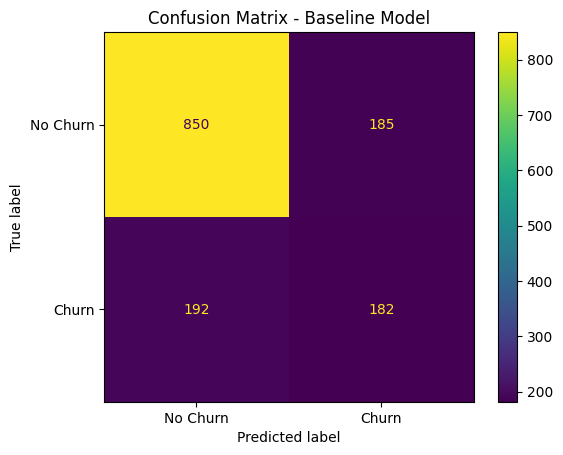

In [10]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Task 10: Compute metrics on the test set
acc = accuracy_score(y_test, test_pred)
prec = precision_score(y_test, test_pred)
rec = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

results_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [acc, prec, rec, f1]
})
print(results_table)

# Task 11: Plot the confusion matrix
cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot()
plt.title('Confusion Matrix - Baseline Model')
plt.show()

In [11]:
#Task 12 
#Since our data is imbalanced (~73% No, ~27% Yes), 
#accuracy alone is misleading — a model predicting "No Churn" for everyone would still score ~73%. 
#Recall and F1-score are more trustworthy here because they show how well the model actually catches churners, which matters more for the business.

In [12]:
#Part 6 
# Task 13: Compare baseline train vs test accuracy
train_acc_baseline = accuracy_score(y_train, train_pred)
test_acc_baseline = accuracy_score(y_test, test_pred)

print("Baseline Train Accuracy:", train_acc_baseline)
print("Baseline Test Accuracy:", test_acc_baseline)

Baseline Train Accuracy: 0.9980475683351083
Baseline Test Accuracy: 0.7324343506032647


In [13]:
# Task 14: Train trees at different max_depth values
depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, clf.predict(X_train))
    te_acc = accuracy_score(y_test, clf.predict(X_test))
    results.append({
        'max_depth': d if d is not None else 'None (unrestricted)',
        'train_acc': tr_acc,
        'test_acc': te_acc
    })

results_df = pd.DataFrame(results)
print(results_df)

             max_depth  train_acc  test_acc
0                    2   0.791090  0.787083
1                    3   0.791090  0.787083
2                    4   0.792510  0.795600
3                    5   0.802272  0.794180
4                    6   0.810614  0.800568
5                    8   0.835818  0.782115
6                   10   0.872737  0.757275
7  None (unrestricted)   0.998048  0.732434


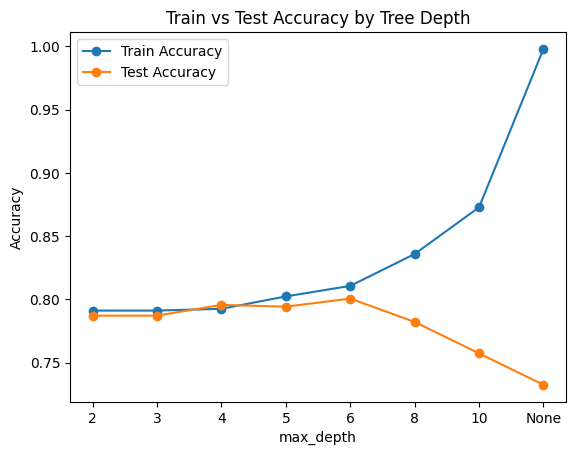

In [14]:
# Task 15: Plot train vs test accuracy against max_depth
x_labels = [str(d) for d in depths]

plt.plot(x_labels, results_df['train_acc'], marker='o', label='Train Accuracy')
plt.plot(x_labels, results_df['test_acc'], marker='o', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy by Tree Depth')
plt.legend()
plt.show()

In [15]:
#Part 7 
# Task 17: Retrain at chosen depth, report full metrics
best_depth = 5  # <-- replace with your actual choice from the Part 6 table/plot

final_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)

final_acc = accuracy_score(y_test, final_pred)
final_prec = precision_score(y_test, final_pred)
final_rec = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)

print("Final Model (max_depth=%s)" % best_depth)
print(pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [final_acc, final_prec, final_rec, final_f1]
}))

Final Model (max_depth=5)
      Metric     Score
0   Accuracy  0.794180
1  Precision  0.631250
2     Recall  0.540107
3   F1-score  0.582133


In [16]:
# Task 18: Retrain with entropy criterion at the same depth, report metrics
entropy_model = DecisionTreeClassifier(max_depth=best_depth, criterion='entropy', random_state=42)
entropy_model.fit(X_train, y_train)
entropy_pred = entropy_model.predict(X_test)

entropy_acc = accuracy_score(y_test, entropy_pred)
entropy_prec = precision_score(y_test, entropy_pred)
entropy_rec = recall_score(y_test, entropy_pred)
entropy_f1 = f1_score(y_test, entropy_pred)

print("Entropy Model (max_depth=%s)" % best_depth)
print(pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [entropy_acc, entropy_prec, entropy_rec, entropy_f1]
}))

Entropy Model (max_depth=5)
      Metric     Score
0   Accuracy  0.792051
1  Precision  0.648352
2     Recall  0.473262
3   F1-score  0.547141


tenure                                 0.422047
InternetService_Fiber optic            0.358061
PaymentMethod_Electronic check         0.036814
TotalCharges                           0.035199
MonthlyCharges                         0.027418
MultipleLines_Yes                      0.023665
OnlineSecurity_No internet service     0.020699
Contract_Two year                      0.019628
StreamingMovies_No internet service    0.017404
TechSupport_Yes                        0.013007
dtype: float64


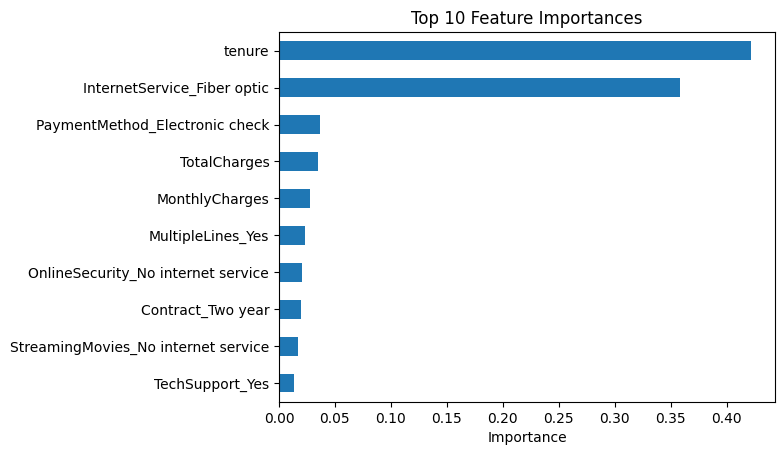

In [17]:
# Task 19: Feature importance
importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.show()

Task 20
The top features, which are tenure, InternetService_Fiber optic, and PaymentMethod_Electronic check, are also matching with what I found in Lab 2 EDA. In Lab 2, I found that churn customers had much lower median tenure, around 10 months, while non-churn customers had 38 months. This shows that new customers have more chances to leave, and this is also matching with tenure being the most important feature in the model.

I also found that customers who use Electronic check had 45.3% churn rate, which is around 2.5 to 3 times higher than other payment methods. This is also matching because Electronic check is the third important feature in the model. Fiber optic internet was also important in my Lab 2 EDA because it was the most common internet service and maybe also more expensive. This is consistent with Fiber optic being the second most important feature.

Overall, the model results are supporting the same churn patterns that I already found from my EDA in Lab 2.


Task 21

I selected a Decision Tree with `max_depth=[your chosen depth]`, which gave [accuracy]% accuracy on the test data. It performed better than the basic tree, which was overfitting. Gini and entropy gave almost similar results, so controlling the tree depth was more important. The main problem is that the model still misses some churn customers and depends mostly on three features: tenure, fiber optic, and electronic check.


Task 22

If I had more time, I would handle the class imbalance using `class_weight='balanced'` or SMOTE. I would also try feature engineering, like charges per month of tenure. Lastly, I would test models like Logistic Regression and Random Forest to see if they perform better than the Decision Tree.



In [18]:
#Task 23 
import pandas as pd
import math
from collections import Counter

play_df = pd.DataFrame({
    'Outlook':     ['Sunny','Sunny','Overcast','Rainy','Rainy','Rainy','Overcast','Sunny','Sunny','Rainy','Sunny','Overcast','Overcast','Rainy'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Windy':       ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis':  ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
})

def entropy(labels):
    counts = Counter(labels)
    total = len(labels)
    return -sum((c/total) * math.log2(c/total) for c in counts.values())

def info_gain(data, attribute, target_col):
    total_entropy = entropy(data[target_col])
    values = data[attribute].unique()
    weighted_entropy = 0
    for v in values:
        subset = data[data[attribute] == v]
        weighted_entropy += (len(subset)/len(data)) * entropy(subset[target_col])
    gain = total_entropy - weighted_entropy
    print(f"  Gain({attribute}) = {gain:.4f}")
    return gain

def id3(data, attributes, target_col, depth=0):
    labels = data[target_col].unique()
    if len(labels) == 1:
        return labels[0]
    if not attributes:
        return Counter(data[target_col]).most_common(1)[0][0]

    print(f"{'  '*depth}Evaluating split on: {attributes} (n={len(data)})")
    gains = {attr: info_gain(data, attr, target_col) for attr in attributes}
    best_attr = max(gains, key=gains.get)
    print(f"{'  '*depth}--> Splitting on: {best_attr}\n")

    tree = {best_attr: {}}
    remaining_attrs = [a for a in attributes if a != best_attr]

    for v in data[best_attr].unique():
        subset = data[data[best_attr] == v]
        if len(subset) == 0:
            tree[best_attr][v] = Counter(data[target_col]).most_common(1)[0][0]
        else:
            tree[best_attr][v] = id3(subset, remaining_attrs, target_col, depth+1)

    return tree

attributes = ['Outlook', 'Temperature', 'Humidity', 'Windy']
print(f"Root entropy of PlayTennis: {entropy(play_df['PlayTennis']):.4f}\n")
tree = id3(play_df, attributes, 'PlayTennis')
print("\nFinal Tree:")
import pprint
pprint.pprint(tree)

Root entropy of PlayTennis: 0.9403

Evaluating split on: ['Outlook', 'Temperature', 'Humidity', 'Windy'] (n=14)
  Gain(Outlook) = 0.2467
  Gain(Temperature) = 0.0292
  Gain(Humidity) = 0.1518
  Gain(Windy) = 0.0481
--> Splitting on: Outlook

  Evaluating split on: ['Temperature', 'Humidity', 'Windy'] (n=5)
  Gain(Temperature) = 0.5710
  Gain(Humidity) = 0.9710
  Gain(Windy) = 0.0200
  --> Splitting on: Humidity

  Evaluating split on: ['Temperature', 'Humidity', 'Windy'] (n=5)
  Gain(Temperature) = 0.0200
  Gain(Humidity) = 0.0200
  Gain(Windy) = 0.9710
  --> Splitting on: Windy


Final Tree:
{'Outlook': {'Overcast': 'Yes',
             'Rainy': {'Windy': {'Strong': 'No', 'Weak': 'Yes'}},
             'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}}}


Outlook has the highest information gain (0.2467), so it becomes the root. For Overcast, all results are Yes, so it stops there. Sunny splits using Humidity, while Rainy splits using Windy, and both separate Yes and No correctly. This is the same as the standard ID3 tree, so it shows the implementation is working correctly.
